Założenia modelowe:
1) Analizujemy tylko Francje europejską + Korsyka 
2) Typy transakcji i ceny łączne (w Euro) powinny być jednakowe w obrębie każdej transakcji
3) Wypełnione `land_use` w rekordach z wyszczególnionym lokalem (lub nie) oznacza uwzględnienie gruntu w transakcji
4) Komponenty ulegające sprzedaży powinny być jednoznacznie określone (bez ryzyka duplikatów)
5) Rozważamy tylko transakcje z gruntami o jednym sposobie zagospodarowania
6) Transakcje mieszkaniowe powinny być bez uwzględniania gruntów
7) Analizujemy tylko transakcje związane ze sprzedażą
8) Lokalizacje działek na których odbywa się sprzedaż powinny być identyfikowalne w przestrzeni
9) Ceny transakcji powinny być uzupełnione
10) Powierzchnia mieszkań i domów (niekoniecznie pomieszczeń dodatkowych) powinna być uzupełniona

Najpierw ustalamy **scope georaficzny** pracy (pkt. 1). Brak spełnienia pkt. 2, 4, 8, 9, 10 traktujemy jako **błąd (wadę) danych**, więc odrazu redukujemy zbiór. 
Pkt. 6, 7 traktujemy jako **scope obiektów do modelowania ceny** i uwzględniamy dopiero przy wstępnym próbkowaniu na końcu skryptu (nie uwzględniamy procesu wstępnego próbkowania w pracy licencjackiej, dopiero wspomnimy o finalnych próbkach przed analizą 1-, wielowymiarową - robimy to, aby zminimalizować zużycie pamięci).

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import branca.colormap as cm

In [2]:
## DEFINICJE ##

# CHARAKTERYSTYKI UŻYTKOWANIA DZIAŁKI/LOKALU (pozwala nam określić jednoznacznie dany fragment gruntu/obiekt w sposób rozmyty)#
plot_cols = ['land_use', 'special_land_use', 'land_area']
object_cols = ['local_type', 'built_surface', 'number_of_rooms']

# MAPY #

# europejska cześć z regionami
france_regions_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/regions.geojson" 

# europejska część z departamentami + zamorskie części
france_departments_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/departements-version-simplifiee.geojson"
guadeloupe_departments_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/departements/971-guadeloupe/departement-971-guadeloupe.geojson"
martinique_departments_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/departements/972-martinique/departement-972-martinique.geojson" 
guyane_departments_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/departements/973-guyane/departement-973-guyane.geojson"
la_reunion_departments_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/departements/974-la-reunion/departement-974-la-reunion.geojson"
mayotte_departments_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/departements/976-mayotte/departement-976-mayotte.geojson"

# TRZCIONKA NA WYKRESACH #
plt.rcParams.update({"axes.titlesize": 11.5, "axes.labelsize": 10, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5})

size = []

0. MAPY PODZIAŁU ADMINISTRACYJNEGO FRANCJI

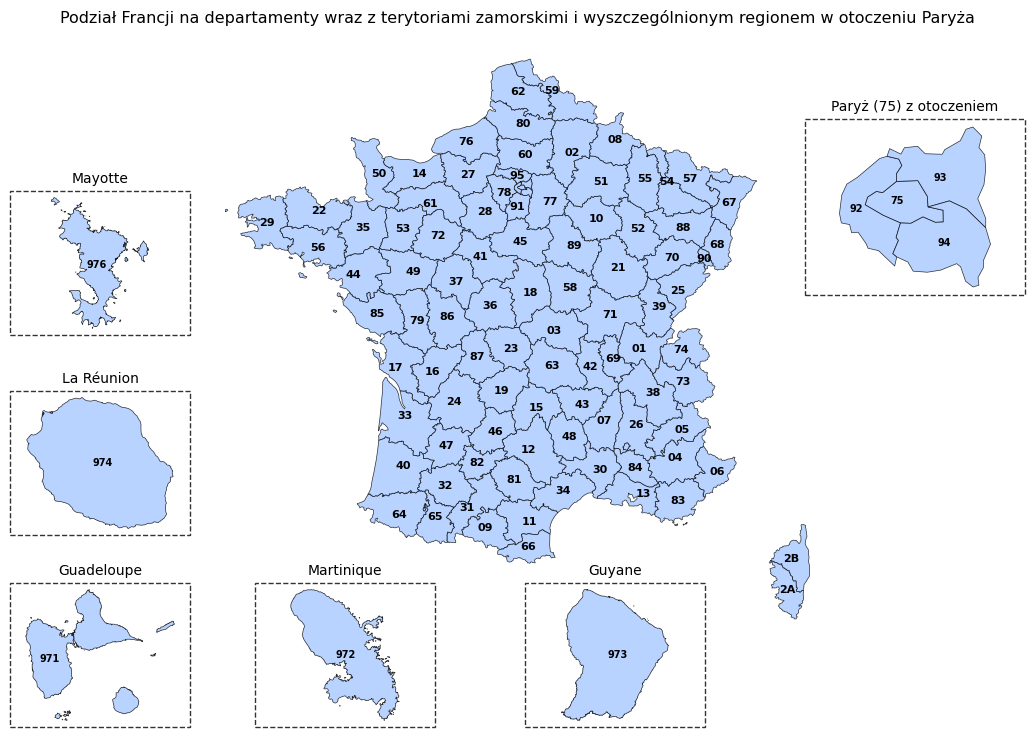

In [3]:
## wykres do pracy przedstawiający podział administracyjny - DEPARTMANETY ##

paris_codes  = ["75", "92", "93", "94"] # Paryż + 3 małe departamenty wokół
overseas_codes = ["971", "972", "973", "974", "976"] # terytoria zamorskie

# MAIN #
gdf_main = gpd.read_file(france_departments_map_url)
gdf_main = gdf_main[~gdf_main["code"].isin(overseas_codes)]

fig, ax_main = plt.subplots(figsize=(10, 8))
gdf_main.plot(ax=ax_main, edgecolor="black", linewidth=0.5, alpha=0.8, facecolor="#a6c8ff")

for _, row in gdf_main.iterrows():
    if row.code in paris_codes:
        continue
    x, y = row.geometry.representative_point().coords[0]
    ax_main.text(x, y, row["code"], ha="center", va="center", fontsize=8, fontweight="bold")

ax_main.set_axis_off()
ax_main.set_title("Podział Francji na departamenty wraz z terytoriami zamorskimi i wyszczególnionym regionem w otoczeniu Paryża")

# PARYŻ #
gdf_paris = gdf_main[gdf_main["code"].isin(paris_codes)]

inset_positions = {
    "Guadeloupe": [0.005, 0.01, 0.18, 0.18],
    "Martinique": [0.25, 0.01, 0.18, 0.18],
    "Guyane": [0.52, 0.01, 0.18, 0.18],
    "La Réunion": [0.005, 0.25, 0.18, 0.18],
    "Mayotte": [0.005, 0.50, 0.18, 0.18],
    "Paris": [0.80, 0.55, 0.22, 0.22],
}


x0, y0, w, h = inset_positions["Paris"]
ax_paris = fig.add_axes([x0, y0, w, h])

gdf_paris.plot(ax=ax_paris, edgecolor="black", linewidth=0.5, alpha=0.8, facecolor="#a6c8ff")

for _, row in gdf_paris.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax_paris.text(x, y, row["code"], ha="center", va="center", fontsize=7, fontweight="bold")

ax_paris.set_axis_off()
ax_paris.set_title("Paryż (75) z otoczeniem", fontsize=10)


rect_paris = Rectangle((x0, y0), w, h, transform=fig.transFigure, fill=False, linestyle="--", linewidth=1.0, edgecolor="black", alpha=0.8, zorder=10)
fig.patches.append(rect_paris)


# TERYTORIA ZAMORSKIE #
dom_urls = {"Guadeloupe": guadeloupe_departments_map_url, "Martinique": martinique_departments_map_url, "Guyane": guyane_departments_map_url,
    "La Réunion": la_reunion_departments_map_url, "Mayotte": mayotte_departments_map_url}

for name, url in dom_urls.items():
    gdf_dom = gpd.read_file(url)

    x0, y0, w, h = inset_positions[name]
    ax_inset = fig.add_axes([x0, y0, w, h])

    gdf_dom.plot(ax=ax_inset, edgecolor="black", linewidth=0.5, alpha=0.8, facecolor="#a6c8ff")
    row0 = gdf_dom.iloc[0]
    x, y = row0.geometry.representative_point().coords[0]
    ax_inset.text(x, y, row0["code"], ha="center", va="center", fontsize=7, fontweight="bold")

    ax_inset.set_axis_off()
    ax_inset.set_title(name, fontsize=10)

    rect = Rectangle((x0, y0), w, h, transform=fig.transFigure, fill=False, linestyle="--", linewidth=1.0, edgecolor="black", alpha=0.8, zorder=10)
    fig.patches.append(rect)

plt.show()

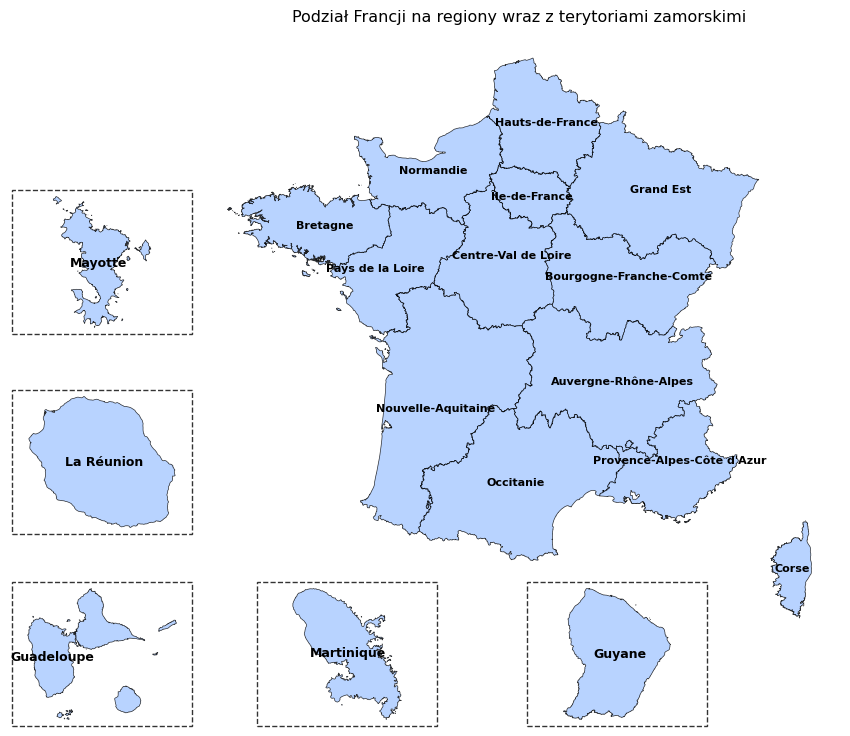

In [4]:
## wykres do pracy przedstawiający podział administracyjny - REGIONY ##

gdf_regions = gpd.read_file(france_regions_map_url)

# MAIN #
fig, ax = plt.subplots(figsize=(10, 8))
gdf_regions.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.8, facecolor="#a6c8ff")

offsets = {"Pays de la Loire": (-0.3, 0.0), "Centre-Val de Loire": (0.3, 0.0)}

for _, row in gdf_regions.iterrows():
    p = row.geometry.representative_point()
    dx, dy = offsets.get(row["nom"], (0, 0))
    ax.text(p.x + dx, p.y + dy, row["nom"],
            fontsize=8, ha="center", va="center", fontweight="bold")

ax.set_axis_off()
ax.set_title("Podział Francji na regiony wraz z terytoriami zamorskimi")

# TERYTORIA ZAMORSKIE #

dom_urls = {"Guadeloupe": guadeloupe_departments_map_url, "Martinique": martinique_departments_map_url, "Guyane": guyane_departments_map_url, 
            "La Réunion": la_reunion_departments_map_url, "Mayotte": mayotte_departments_map_url}

inset_positions = {
    "Guadeloupe": [0.005, 0.01, 0.18, 0.18],
    "Martinique": [0.25, 0.01, 0.18, 0.18],
    "Guyane": [0.52, 0.01, 0.18, 0.18],
    "La Réunion": [0.005, 0.25, 0.18, 0.18],
    "Mayotte": [0.005, 0.50, 0.18, 0.18],
}


for name, url in dom_urls.items():
    gdf_dom = gpd.read_file(url)

    x0, y0, w, h = inset_positions[name]
    ax_inset = fig.add_axes([x0, y0, w, h])

    ax_inset.set_axis_off()
    ax_inset.patch.set_alpha(0)
    ax_inset.set_frame_on(False)
    for sp in ax_inset.spines.values():
        sp.set_visible(False)

    gdf_dom.plot(ax=ax_inset, edgecolor="black", linewidth=0.5, alpha=0.8, facecolor="#a6c8ff")

    rect = Rectangle((x0, y0), w, h, transform=fig.transFigure, fill=False, linestyle="--", linewidth=1.0, edgecolor="black", alpha=0.8, zorder=10)
    fig.patches.append(rect)


    row0 = gdf_dom.iloc[0]
    p0 = row0.geometry.representative_point()
    ax_inset.text(p0.x, p0.y, row0["nom"], ha="center", va="center", fontsize=9, fontweight="bold")

plt.show()

1. WCZYTANIE I WSTĘPNE PRZYGOTOWANIE DANYCH DO PRACY

In [3]:
# 2017-2024

years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
data_size = []

data = pd.DataFrame()
i = 0

for year in years:
    
    filename = f"D:\\nieruchomosci_ostateczne\\data\\full_{year}.csv"
    new = pd.read_csv(filename, low_memory=False)
    
    i+=1
    print(f'{i}/{len(years)}')
    
    data = pd.concat([data, new])
    data_size.append(len(new))

print(data_size)
size.append(len(data))

1/8
2/8
3/8
4/8
5/8
6/8
7/8
8/8
[3381190, 3319426, 3142952, 827105, 4674176, 4675007, 3812327, 3489149]


tłumaczymy z francuskiego nazwy kolumn

In [6]:
col_names = [
    'transaction_id',             # id_mutation
    'transaction_date',           # date_mutation
    'disposition_number',         # numero_disposition
    'transaction_type',           # nature_mutation
    'property_value',             # valeur_fonciere
    'address_number',             # adresse_numero
    'address_suffix',             # adresse_suffixe
    'street_name',                # adresse_nom_voie
    'street_code',                # adresse_code_voie
    'postal_code',                # code_postal
    'commune_code',               # code_commune
    'commune_name',               # nom_commune
    'department_code',            # code_departement
    'old_commune_code',           # ancien_code_commune
    'old_commune_name',           # ancien_nom_commune
    'parcel_id',                  # id_parcelle
    'old_parcel_id',              # ancien_id_parcelle
    'volume_number',             # numero_volume
    'lot1_number',                # lot1_numero
    'lot1_surface',               # lot1_surface_carrez
    'lot2_number',                # lot2_numero
    'lot2_surface',               # lot2_surface_carrez
    'lot3_number',                # lot3_numero
    'lot3_surface',               # lot3_surface_carrez
    'lot4_number',                # lot4_numero
    'lot4_surface',               # lot4_surface_carrez
    'lot5_number',                # lot5_numero
    'lot5_surface',               # lot5_surface_carrez
    'number_of_lots',             # nombre_lots
    'local_type_code',            # code_type_local
    'local_type',                 # type_local
    'built_surface',              # surface_reelle_bati
    'number_of_rooms',            # nombre_pieces_principales
    'land_use_code',              # code_nature_culture
    'land_use',                   # nature_culture
    'special_land_use_code',      # code_nature_culture_speciale
    'special_land_use',           # nature_culture_speciale
    'land_area',                  # surface_terrain
    'longitude',                  # longitude
    'latitude'                    # latitude
]

data.columns = col_names

tłumaczymy nazwy wartości cech kategorycznych z francuskiego

In [7]:
translation1 = {
    'Vente': 'Sale',
    "Vente en l'état futur d'achèvement": 'Off-plan sale',
    'Echange': 'Exchange',
    'Vente terrain à bâtir': 'Land sale',
    'Adjudication': 'Auction',
    'Expropriation': 'Expropriation'
}


translation2 = {
    'Dépendance': 'Outbuilding',
    'Maison': 'House',
    'Appartement': 'Apartment',
    'Local industriel. commercial ou assimilé': 'Commercial/Industrial'
}

translation3 = {
    'sols': 'bare soil',
    'taillis simples': 'simple coppices',
    'prés': 'meadows',
    'terres': 'arable land',
    'taillis sous futaie': 'coppices under high forest',
    'terrains a bâtir': 'building land',
    'jardins': 'gardens',
    "terrains d'agrément": 'recreational land',
    'peupleraies': 'poplar plantations',
    'landes': 'moors',
    'vignes': 'vineyards',
    'vergers': 'orchards',
    'eaux': 'water areas',
    'pâtures': 'pastures',
    'bois': 'woods',
    'futaies résineuses': 'coniferous high forests',
    'futaies mixtes': 'mixed high forests',
    'futaies feuillues': 'deciduous high forests',
    'oseraies': 'osier beds',
    'carrières': 'quarries',
    'chemin de fer': 'railway',
    'pacages': 'grazing land',
    'prés plantes': 'planted meadows',
    'terres plantées': 'planted lands',
    'landes boisées': 'wooded moors',
    'herbages': 'grassland',
    "prés d'embouche": 'fattening meadows'
}

data['transaction_type'] = data['transaction_type'].replace(translation1)
print(data.transaction_type.unique())

data['local_type'] = data['local_type'].replace(translation2)
print(data.local_type.unique())

data['land_use'] = data['land_use'].replace(translation3)
print(data.land_use.unique())

['Sale' 'Off-plan sale' 'Exchange' 'Land sale' 'Auction' 'Expropriation']
['Apartment' nan 'Outbuilding' 'House' 'Commercial/Industrial']
[nan 'building land' 'meadows' 'bare soil' 'arable land' 'gardens'
 'coppices under high forest' 'vineyards' 'simple coppices'
 'recreational land' 'moors' 'poplar plantations' 'orchards' 'water areas'
 'woods' 'quarries' 'coniferous high forests' 'mixed high forests'
 'pastures' 'deciduous high forests' 'railway' 'planted meadows'
 'grazing land' 'osier beds' 'planted lands' 'wooded moors' 'grassland'
 'fattening meadows']


filtrujemy obiekty na terenie Europy (część kontynentalna + Korsyka)

In [8]:
print(f"liczba braków kodów departamentów: {data.department_code.isna().sum()}")
print(f'departamenty: {data.department_code.unique()}')

data = data[~data.department_code.isin(["971", "972", "973", "974", "976"])] # wyrzucamy tereny zamorskie
size.append(len(data))

liczba braków kodów departamentów: 0
departamenty: ['01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '11' '12' '13' '14'
 '50' '15' '16' '17' '18' '19' '21' '22' '23' '24' '25' '26' '27' '28'
 '29' '2A' '2B' '30' '31' '32' '33' '34' '35' '36' '37' '38' '39' '40'
 '41' '42' '43' '44' '45' '46' '47' '48' '49' '51' '52' '53' '54' '55'
 '56' '58' '59' '60' '61' '62' '63' '64' '65' '66' '69' '70' '71' '72'
 '73' '74' '76' '77' '78' '79' '80' '81' '82' '83' '84' '85' '86' '87'
 '88' '89' '90' '91' '92' '93' '94' '95' '971' '972' '973' '974' '75']


In [9]:
## zmienne czasowe: dokładna data, miesiąc_rok, miesiąc, rok ##

data['transaction_date'] = pd.to_datetime(data.transaction_date)
data['month_year'] = data['transaction_date'].dt.to_period('M')
data['month'] = data['transaction_date'].dt.month
data['year'] = data['transaction_date'].dt.year
data['quarter'] = data['transaction_date'].dt.quarter

In [10]:
data.loc[data.local_type.isna(), "local_type"] = "Other" # tutaj chodzi zapewne o kupno związane z ziemiami 

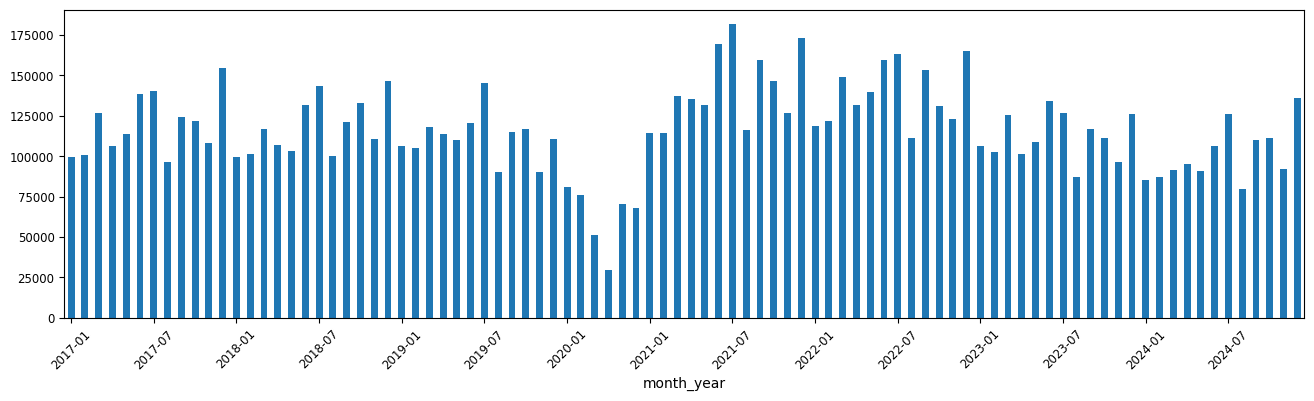

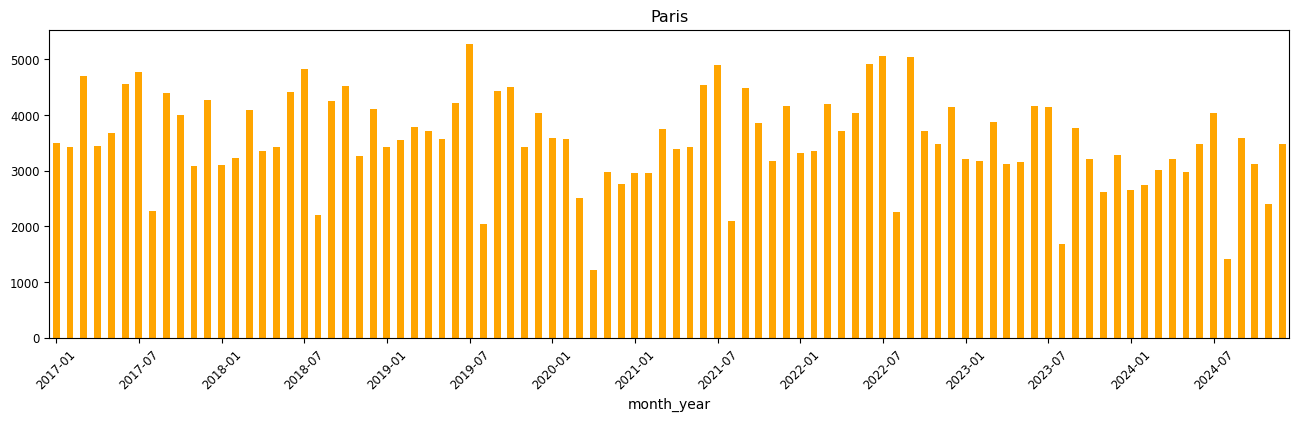

In [11]:
# WYKRES KONTROLNY: LICZBA TRANSAKCJI W POSZCZEGÓLNYCH MIESIĄCACH #

s = data.drop_duplicates('transaction_id').groupby('month_year').size()
ax = s.plot(kind='bar', figsize=(16,4))
step = 6
ax.set_xticks(range(0, len(s), step))
ax.set_xticklabels(s.index[::step], rotation=45)
plt.show()

s = data[data.department_code == '75'].drop_duplicates('transaction_id').groupby('month_year').size()
ax = s.plot(kind='bar', figsize=(16,4), color = 'orange')
step = 6
ax.set_xticks(range(0, len(s), step))
ax.set_xticklabels(s.index[::step], rotation=45)
ax.set_title('Paris')

plt.show()

ułamek liczby transakcji o niejednolitym typie sprzedaży 2.7448226973201094e-05
liczba transakcji o niejednakowej wartości pieniężnej 0
[8599238, 0, 804]


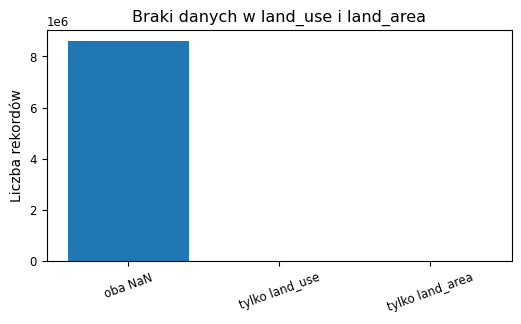

In [12]:
## każda transakcja jest jednolitym typem ##

key = pd.MultiIndex.from_frame(data[["transaction_type"]])
code = pd.Series(pd.factorize(key)[0], index=data.index)
many_values = code.groupby([data["transaction_id"]]).transform("nunique").gt(1)
many_types_transactions = data.loc[many_values, "transaction_id"].unique()

print(f'ułamek liczby transakcji o niejednolitym typie sprzedaży {len(many_types_transactions) / data["transaction_id"].nunique()}')

data = data[~data["transaction_id"].isin(many_types_transactions)]
size.append(len(data))

## w każdej transakcji cena jest jednolita i łączna nawet jeśli jest > 1 dispositions ##

key = pd.MultiIndex.from_frame(data[["property_value"]])
code = pd.Series(pd.factorize(key)[0], index=data.index)
many_values = code.groupby([data["transaction_id"]]).transform("nunique").gt(1)
many_values_transactions = data.loc[many_values, ["transaction_id"]].drop_duplicates()

print(f'liczba transakcji o niejednakowej wartości pieniężnej {len(many_values_transactions)}')

## czy braki danych w charakterystykach gruntu są konsekwentne ? Czyli czy powierzchnia działki i przeznaczenie gruntu konsekwetnie są brakujące razem ##

lu_na = data["land_use"].isna()
la_na = data["land_area"].isna()
both_na = (lu_na & la_na).sum()
only_lu_na = (lu_na & ~la_na).sum()
only_la_na = (~lu_na & la_na).sum()

labels = ["oba NaN", "tylko land_use", "tylko land_area"]
values = [both_na, only_lu_na, only_la_na]
print(values)

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(labels, values)
ax.set_title("Braki danych w land_use i land_area")
ax.set_ylabel("Liczba rekordów")
ax.tick_params(axis="x", rotation=20)
plt.show()

2. TRANSAKCJE Z KILKOMA SPOSOBAMI ZAGOSPODAROWANIA GRUNTU - DUPLIKATY

In [13]:
## sprawdzamy czy w transakcji jest kilka różnych użytkowań gruntu danej działki - wtedy mamy duplikaty ##

mask = data["land_use"].notna() # zakładamy że missingi w użytkowaniu gruntu nie są duplikatami
X = data.loc[mask, plot_cols].fillna("__MISSING__") # Nan traktujemy jako element klucza - dla bezpieczeństwa możemy usunąć
#X = data.loc[mask, plot_cols]

code = pd.Series(pd.factorize(pd.MultiIndex.from_frame(X))[0], index=X.index)

g = data.loc[mask, ["transaction_id", "parcel_id"]]

is_bad_pair_masked = code.groupby([g["transaction_id"], g["parcel_id"]]).transform("nunique").gt(1)
is_bad_pair = pd.Series(False, index=data.index)
is_bad_pair.loc[mask] = is_bad_pair_masked


bad_pairs = data.loc[is_bad_pair, ["transaction_id", "parcel_id"]].drop_duplicates()
n_bad_records = data.loc[is_bad_pair, :].size
n_bad_pairs = len(bad_pairs)
n_bad_transaction_ids = bad_pairs["transaction_id"].nunique()

to_remove = bad_pairs["transaction_id"].unique() # transaction_id z kupnem wielu różnych użytkowań gruntów

all_pairs = data[["transaction_id", "parcel_id"]].drop_duplicates()
n_proper_pairs = len(all_pairs) - n_bad_pairs
n_proper_records = data.size - n_bad_records 
n_proper_transaction_ids = all_pairs["transaction_id"].nunique() - n_bad_transaction_ids

In [14]:
# PRZYKŁADY #

data[(data.transaction_id == '2017-10973')].loc[:,['local_type', 'transaction_date', 'transaction_id', 'land_area', 'land_use',
                                                    'special_land_use', 'built_surface', 'number_of_rooms', 'department_code', 'commune_name', 'parcel_id', 'property_value']]

,local_type,transaction_date,transaction_id,land_area,land_use,special_land_use,built_surface,number_of_rooms,department_code,commune_name,parcel_id,property_value
28327,Other,2017-02-27,2017-10973,200.0,recreational land,NaN,NaN,NaN,01,Le Plantay,012990000A0742,134400.0
28328,Other,2017-02-27,2017-10973,182.0,recreational land,NaN,NaN,NaN,01,Le Plantay,012990000A0742,134400.0
28329,Outbuilding,2017-02-27,2017-10973,NaN,NaN,NaN,NaN,0.0,01,Le Plantay,012990000A0742,134400.0
28330,Apartment,2017-02-27,2017-10973,NaN,NaN,NaN,101.0,3.0,01,Le Plantay,012990000A0742,134400.0


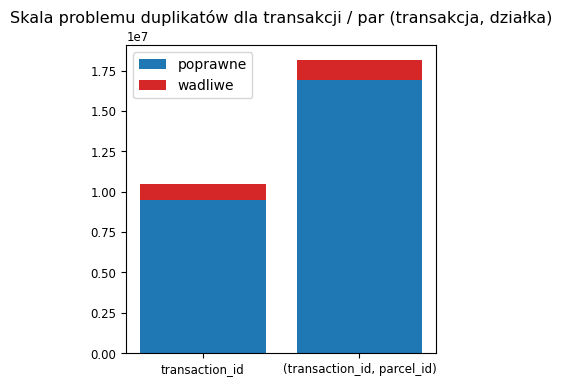

In [15]:
# WYKRES #

labels = ["transaction_id", "(transaction_id, parcel_id)"]
all_values = [n_proper_transaction_ids, n_proper_pairs]
bad_values = [n_bad_transaction_ids, n_bad_pairs]

x = np.arange(len(labels))
plt.figure(figsize=(4, 4))
plt.title("Skala problemu duplikatów dla transakcji / par (transakcja, działka)")

plt.bar(x, all_values, label="poprawne", color="tab:blue")
plt.bar(x, bad_values, bottom=all_values, label="wadliwe", color="#d62728")

plt.xticks(x, labels, rotation=0)
plt.legend()
plt.show()

In [16]:
# USUWAMY TE TRANSAKCJE ZE WZGLĘDU NA ICH MAŁĄ LICZBE #

# WYJŚCIE A: USUWAMY TYLKO DUPLIKATY W (transaction_id, parcel_id)
# data = pd.concat([data.loc[~is_bad_pair], data.loc[is_bad_pair].drop_duplicates(subset=object_cols, keep="first")], ignore_index=True)

# WYJŚCIE B: USUWAMY WSZYSTKIE transaction_id Z DUPLIKATAMI #
data = data[~data.transaction_id.isin(to_remove)]
size.append(len(data))

3. AGREGATY I SELEKCJA PRÓBEK Z POTENCJAŁEM DO PRACY

In [17]:
# AGREGATY #

counts_by_type = data.groupby(["transaction_id", "local_type"]).size().unstack(fill_value=0).reset_index()
counts_by_type.columns.name = None
counts_by_type = counts_by_type.rename(columns={col: f"n_{col}" for col in counts_by_type.columns if col != "transaction_id"})

counts_by_type_paris = data[data.department_code == '75'].groupby(["transaction_id", "local_type"]).size().unstack(fill_value=0).reset_index()
counts_by_type_paris.columns.name = None
counts_by_type_paris = counts_by_type_paris.rename(columns={col: f"n_{col}" for col in counts_by_type_paris.columns if col != "transaction_id"})

size_by_type = data.groupby(["transaction_id", "local_type"]).built_surface.sum().unstack(fill_value=0).reset_index()
size_by_type.columns.name = None
size_by_type = size_by_type.rename(columns={col: f"size_{col}" for col in size_by_type.columns if col != "transaction_id"})

counts_size_by_type = data.groupby(["transaction_id", "local_type"]).agg(n_size=("built_surface", "count"), n_size_nan=("built_surface", lambda x: x.isna().sum())).unstack(fill_value=0)
counts_size_by_type.columns = [f"{metric}_{localtype}" for metric, localtype in counts_size_by_type.columns]
counts_size_by_type = counts_size_by_type.reset_index()
counts_size_by_type.columns.name = None

# PRÓBKOWANIE #

# transakcje z tylko 1 mieszkaniem
one_apartment_transaction_ids = counts_by_type[(counts_by_type['n_Apartment'] == 1) & (counts_by_type['n_Commercial/Industrial'] == 0) & 
    (counts_by_type['n_House'] == 0) & (counts_by_type['n_Outbuilding'] == 0) & (counts_by_type['n_Other'] == 0)].transaction_id.to_numpy()

# transakcje z 1 mieszkaniem + 1 pomieszczeniem dodatkowym
one_apartment_one_outbuilding_transaction_ids = counts_by_type[(counts_by_type['n_Apartment'] == 1) & (counts_by_type['n_Commercial/Industrial'] == 0) & 
    (counts_by_type['n_House'] == 0) & (counts_by_type['n_Outbuilding'] == 1) & (counts_by_type['n_Other'] == 0)].transaction_id.to_numpy()

# transakcje z 1 mieszkaniem + 2 pomieszczeniami dodatkowymi
one_apartment_two_outbuildings_transaction_ids = counts_by_type[(counts_by_type['n_Apartment'] == 1) & (counts_by_type['n_Commercial/Industrial'] == 0) & 
    (counts_by_type['n_House'] == 0) & (counts_by_type['n_Outbuilding'] == 2) & (counts_by_type['n_Other'] == 0)].transaction_id.to_numpy()

# transakcje z 2 mieszkaniami
two_apartments_transaction_ids = counts_by_type[(counts_by_type['n_Apartment'] == 2) & (counts_by_type['n_Commercial/Industrial'] == 0) & 
    (counts_by_type['n_House'] == 0) & (counts_by_type['n_Outbuilding'] == 0) & (counts_by_type['n_Other'] == 0)].transaction_id.to_numpy()

# transakcje z 1 domem
one_house_transaction_ids = counts_by_type[(counts_by_type['n_Apartment'] == 0) & (counts_by_type['n_Commercial/Industrial'] == 0) & 
    (counts_by_type['n_House'] == 1) & (counts_by_type['n_Outbuilding'] == 0) & (counts_by_type['n_Other'] == 0)].transaction_id.to_numpy()

# transakcje ogólne z mieszkaniami
apartments_transaction_ids = counts_by_type[(counts_by_type['n_Apartment'] > 0) & (counts_by_type['n_House'] == 0)].transaction_id.to_numpy()

# transakcje ogólne z domami
houses_transaction_ids = counts_by_type[(counts_by_type['n_Apartment'] == 0) & (counts_by_type['n_House'] > 0)].transaction_id.to_numpy()


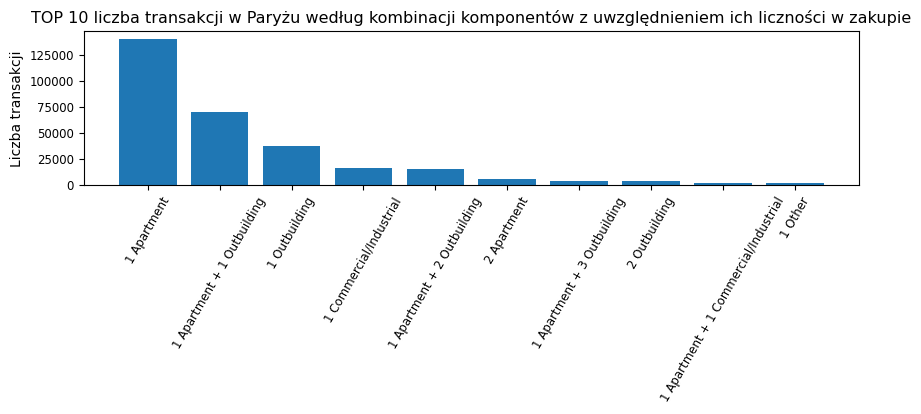

In [18]:
# WYKRES: wizualizacja liczebności obiektów w transakcjach dla PARYŻA 
# wykres 1
counts_paris = counts_by_type_paris.copy()
type_cols = [c for c in counts_paris.columns if c != "transaction_id"]

fig3, ax3 = plt.subplots(figsize=(10, 2))
counts_paris["combo_str"] = counts_paris[type_cols].apply(lambda row: " + ".join([f"{int(row[c])} {c.replace('n_','')}" for c in type_cols if row[c] > 0]), axis=1)
combo_counts_str = counts_paris["combo_str"].value_counts().head(10)

ax3.bar(combo_counts_str.index, combo_counts_str.values, color = "tab:blue")
ax3.set_title("TOP 10 liczba transakcji w Paryżu według kombinacji komponentów z uwzględnieniem ich liczności w zakupie")
ax3.set_ylabel("Liczba transakcji")
ax3.tick_params(axis="x", rotation=60)
plt.show()

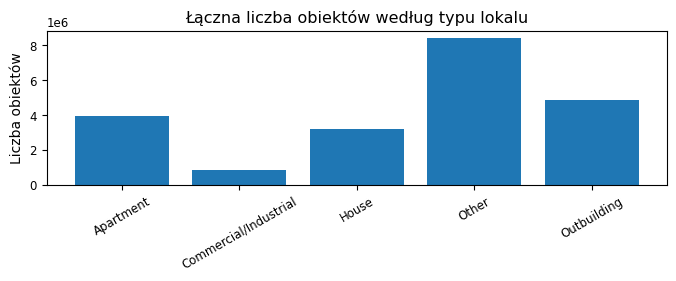

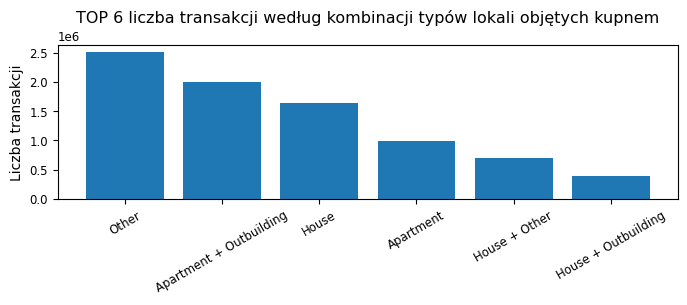

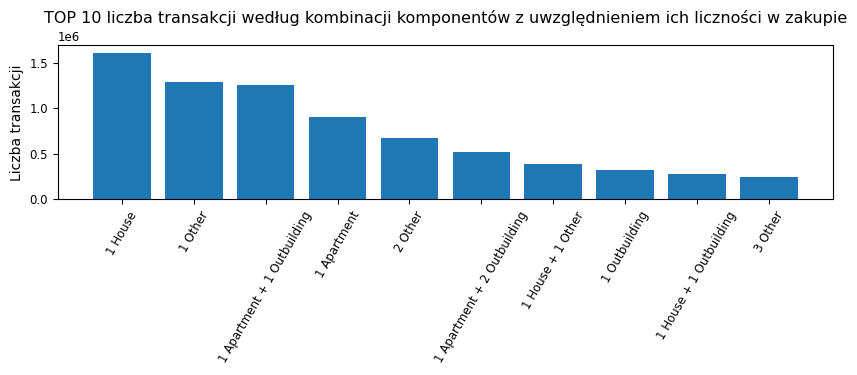

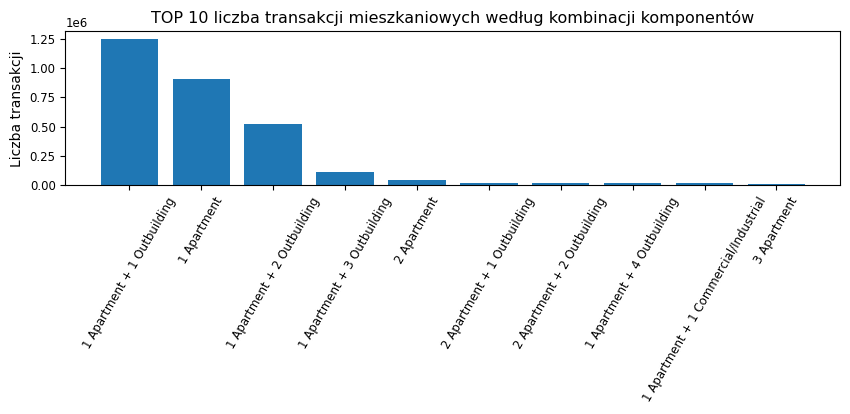

In [19]:
# WYKRES: wizualizacja liczebności obiektów w transakcjach #

counts = counts_by_type.copy()
type_cols = [c for c in counts.columns if c != "transaction_id"]

# wykres 1: łączna liczba obiektów

fig1, ax1 = plt.subplots(figsize=(8, 2))
total_by_type = counts[type_cols].sum()
total_by_type.index = [c.replace("n_", "") for c in total_by_type.index]

ax1.bar(total_by_type.index, total_by_type.values, color = "tab:blue")
ax1.set_title("Łączna liczba obiektów według typu lokalu")
ax1.set_ylabel("Liczba obiektów")
ax1.tick_params(axis="x", rotation=30)
plt.show()

# wykres 2

fig2, ax2 = plt.subplots(figsize=(8, 2))
counts["combo_simple"] = counts[type_cols].apply(lambda row: " + ".join([c.replace("n_", "") for c in type_cols if row[c] > 0]), axis=1)
combo_counts_simple = counts["combo_simple"].value_counts().head(6)

ax2.bar(combo_counts_simple.index.astype(str), combo_counts_simple.values, color = "tab:blue")
ax2.set_title("TOP 6 liczba transakcji według kombinacji typów lokali objętych kupnem")
ax2.set_ylabel("Liczba transakcji")
ax2.tick_params(axis="x", rotation=30)
plt.show()

# wykres 3

fig3, ax3 = plt.subplots(figsize=(10, 2))
counts["combo_str"] = counts[type_cols].apply(lambda row: " + ".join([f"{int(row[c])} {c.replace('n_','')}" for c in type_cols if row[c] > 0]), axis=1)
combo_counts_str = counts["combo_str"].value_counts().head(10)

ax3.bar(combo_counts_str.index, combo_counts_str.values, color = "tab:blue")
ax3.set_title("TOP 10 liczba transakcji według kombinacji komponentów z uwzględnieniem ich liczności w zakupie")
ax3.set_ylabel("Liczba transakcji")
ax3.tick_params(axis="x", rotation=60)
plt.show()

# wykres 4

fig4, ax4 = plt.subplots(figsize=(10, 2))
combo_counts_str_full = counts["combo_str"].value_counts()
only_apartment_combos = combo_counts_str_full[combo_counts_str_full.index.str.contains("Apartment")].head(10)

ax4.bar(only_apartment_combos.index, only_apartment_combos.values, color = "tab:blue")
ax4.set_title("TOP 10 liczba transakcji mieszkaniowych według kombinacji komponentów")
ax4.set_ylabel("Liczba transakcji")
ax4.tick_params(axis="x", rotation=60)
plt.show()

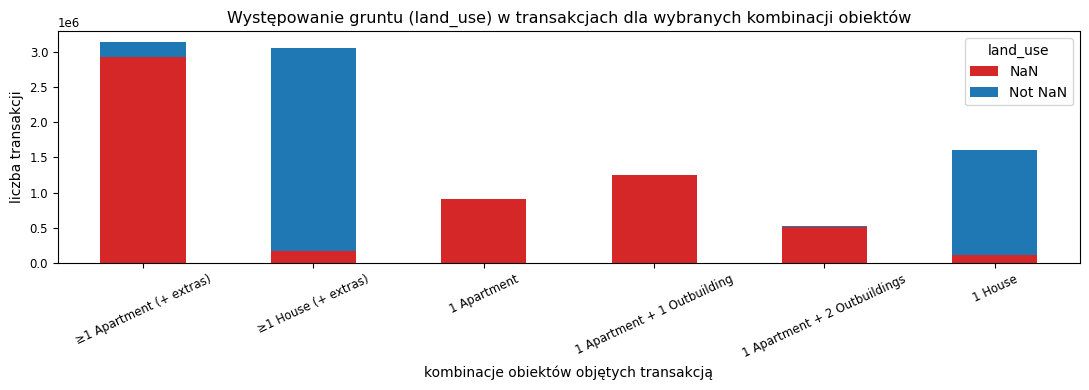

In [20]:
# WYKRES: wizualizujemy rozkłady transakcji związanych z `land_use` - kupno gruntu wchodziło w transakcje #

# próbki
sample_apartments = data[data["transaction_id"].isin(apartments_transaction_ids)]
sample_houses = data[data["transaction_id"].isin(houses_transaction_ids)]
sample_1apartment = data[data["transaction_id"].isin(one_apartment_transaction_ids)]
sample_1apartment_1outbuilding = data[data["transaction_id"].isin(one_apartment_one_outbuilding_transaction_ids)]
sample_1apartment_2outbuilding = data[data["transaction_id"].isin(one_apartment_two_outbuildings_transaction_ids)]
sample_1house = data[data["transaction_id"].isin(one_house_transaction_ids)]  # masz to już wyżej

def land_use_counts(df: pd.DataFrame):

    has_land = df['land_use'].notna().groupby(df['transaction_id']).any()
    
    nan_cnt = (~has_land).sum()
    notnan_cnt = has_land.sum()
    
    value = df.groupby('transaction_id')['property_value'].first().dropna()
    has_land = has_land.reindex(value.index).fillna(False)

    mean_value_has_land = value[has_land].mean()
    mean_value_no_land  = value[~has_land].mean()

    return nan_cnt, notnan_cnt, mean_value_no_land, mean_value_has_land

samples = {
    "≥1 Apartment (+ extras)": sample_apartments,
    "≥1 House (+ extras)": sample_houses,
    "1 Apartment": sample_1apartment,
    "1 Apartment + 1 Outbuilding": sample_1apartment_1outbuilding,
    "1 Apartment + 2 Outbuildings": sample_1apartment_2outbuilding,
    "1 House": sample_1house,
}

rows, rows_value = {}, {}
for name, df in samples.items():

    nan_cnt, notnan_cnt, mean_value_no_land, mean_value_has_land = land_use_counts(df)
    rows[name] = {"NaN": nan_cnt, "Not NaN": notnan_cnt}
    rows_value[name] = {"NaN": mean_value_no_land, "Not NaN": mean_value_has_land}


# wykres 1
plot_counts = pd.DataFrame(rows).T
fig, ax = plt.subplots(figsize=(11, 4))
plot_counts.plot(kind="bar", stacked=True, ax=ax, color=["#d62728", "tab:blue"])

ax.set_title("Występowanie gruntu (land_use) w transakcjach dla wybranych kombinacji obiektów")
ax.set_xlabel("kombinacje obiektów objętych transakcją")
ax.set_ylabel("liczba transakcji")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="land_use", loc="best")

plt.tight_layout()
plt.show()

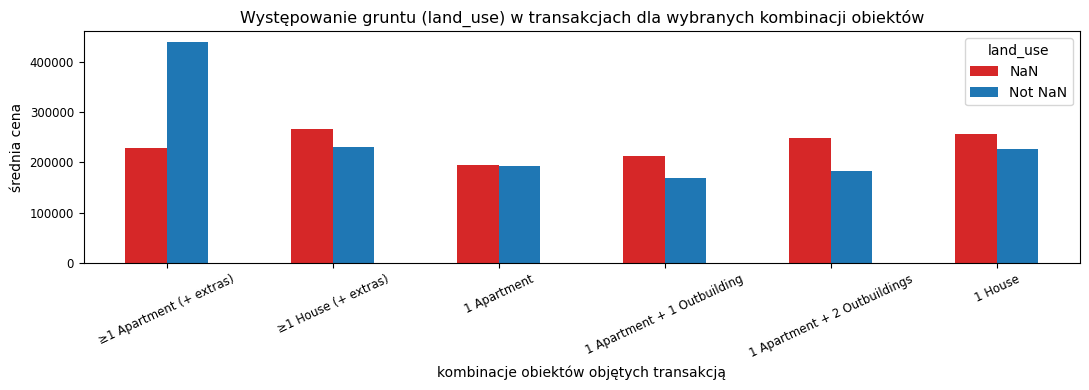

In [21]:
# wykres 2
plot_values = pd.DataFrame(rows_value).T
fig, ax = plt.subplots(figsize=(11, 4))
plot_values.plot(kind="bar", stacked=False, ax=ax, color=["#d62728", "tab:blue"])

ax.set_title("Występowanie gruntu (land_use) w transakcjach dla wybranych kombinacji obiektów")
ax.set_xlabel("kombinacje obiektów objętych transakcją")
ax.set_ylabel("średnia cena")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="land_use", loc="best")

plt.tight_layout()
plt.show()


#del sample_1apartment, sample_1apartment_1outbuilding, sample_1apartment_2outbuilding, sample_1house, sample_apartments, sample_houses

4. ANALIZA TYPÓW TRANSAKCJI

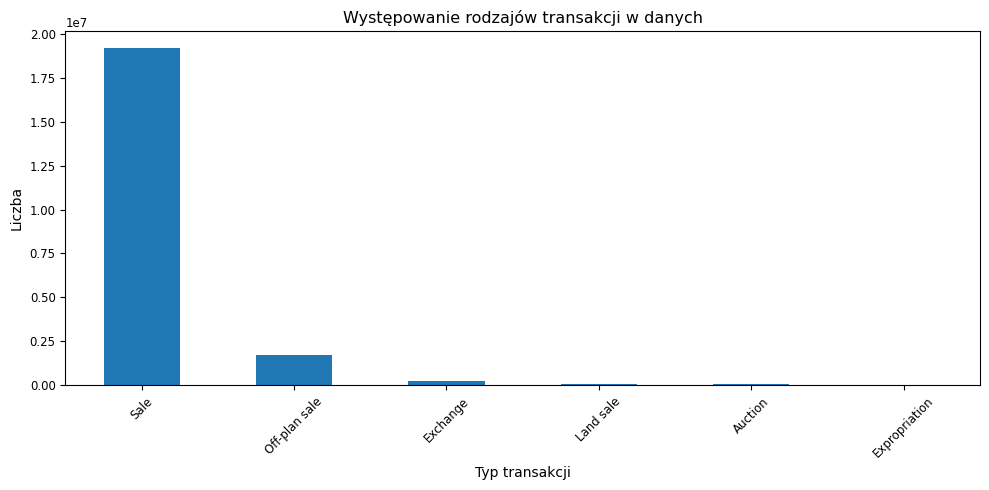

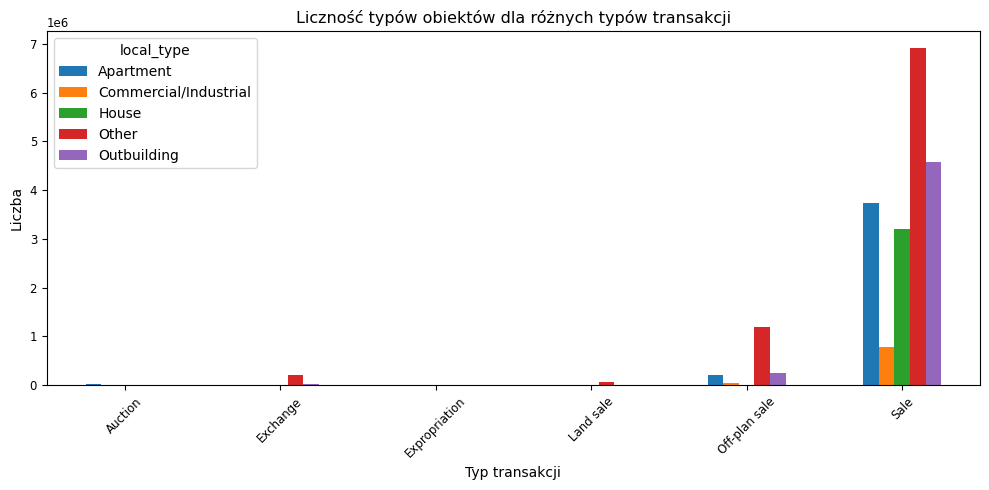

In [22]:
# WYKRES: wizualizacja typów transakcji #

type_transactions = data["transaction_type"].value_counts()
type_transactions.plot(kind="bar", figsize=(10,5), color = "tab:blue")

plt.xticks(rotation=45)
plt.title("Występowanie rodzajów transakcji w danych")
plt.ylabel("Liczba")
plt.xlabel("Typ transakcji")
plt.tight_layout()
plt.show()


type_transactions_build_types = data.groupby("transaction_type")["local_type"].value_counts().unstack(fill_value=0)
type_transactions_build_types.plot(kind="bar", figsize=(10,5))

plt.xticks(rotation=45)
plt.title("Liczność typów obiektów dla różnych typów transakcji")
plt.ylabel("Liczba")
plt.xlabel("Typ transakcji")
plt.tight_layout()
plt.show()

5. BRAKI DANYCH (REDUKCJA NIEZIDENTYFIKOWANYCH REKORDÓW I ZBĘDNYCH KOLUMN)

In [3]:
import pandas as pd
data = pd.read_csv('D:\\nieruchomosci_ostateczne\\samples\\sample_all1.txt', low_memory = False)

In [4]:
data_null = data.isna().sum() / len(data) * 100
data_null = data_null.rename('missing_rate')
data_null = data_null.sort_values(ascending=False)

display(data_null)

remove_col = data_null[data_null > 80].index
data_to_save = data.loc[:, ~data.columns.isin(remove_col)]

built_surface         62.579911
lot1_number           60.321402
land_area             40.279733
land_use              40.278530
land_use_code         40.278530
number_of_rooms       39.608082
local_type_code       39.544304
address_number        34.876561
latitude               2.290448
longitude              2.290448
postal_code            1.036300
street_name            1.033307
street_code            1.030056
property_value         0.786396
transaction_id         0.000000
month                  0.000000
year                   0.000000
month_year             0.000000
number_of_lots         0.000000
local_type             0.000000
transaction_date       0.000000
parcel_id              0.000000
department_code        0.000000
commune_name           0.000000
commune_code           0.000000
transaction_type       0.000000
disposition_number     0.000000
quarter                0.000000
Name: missing_rate, dtype: float64

zapis danych

In [ ]:
data_to_save.to_csv('D:\\nieruchomosci_ostateczne\\samples\\sample_all1.txt', index=False)

np.savetxt("D:\\nieruchomosci_ostateczne\\samples\\one_apartment_transaction_ids.txt", one_apartment_transaction_ids, fmt="%s")
np.savetxt("D:\\nieruchomosci_ostateczne\\samples\\one_apartment_one_outbuilding_transaction_ids.txt", one_apartment_one_outbuilding_transaction_ids, fmt="%s")
np.savetxt("D:\\nieruchomosci_ostateczne\\samples\\one_house_transaction_ids.txt", one_house_transaction_ids, fmt="%s")

np.savetxt("D:\\nieruchomosci_ostateczne\\samples\\houses_transaction_ids.txt", houses_transaction_ids, fmt="%s")
np.savetxt("D:\\nieruchomosci_ostateczne\\samples\\apartments_transaction_ids.txt", apartments_transaction_ids, fmt="%s")

wczytujemy, ciąg dalszy badania brakujących wartości i redukujemy liczbe rekordów (**wstępne próbkowanie**)

In [2]:
data2 = pd.read_csv('D:\\nieruchomosci_ostateczne\\samples\\sample_all1.txt', low_memory = False)
size = [27321332, 27068311, 27066776, 21284570]

ids1 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_transaction_ids.txt", dtype=str)
ids2 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_one_outbuilding_transaction_ids.txt", dtype=str)
ids3 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_house_transaction_ids.txt", dtype=str)

ids_houses = np.loadtxt("D:\\nieruchomosci_ostateczne\\samples\\houses_transaction_ids.txt", dtype=str)
ids_apartments = np.loadtxt("D:\\nieruchomosci_ostateczne\\samples\\apartments_transaction_ids.txt", dtype=str)

all_ids = set(ids1) | set(ids2) | set(ids3) | set(ids_houses) | set(ids_apartments)
apartment_ids = set(ids1) | set(ids2) | set(ids_apartments)

In [3]:
nan_built = data2.loc[data2['built_surface'].isna()].groupby('local_type').size() * 100 / data2.built_surface.isna().sum()
nan_rooms = data2.loc[data2['number_of_rooms'].isna()].groupby('local_type').size() * 100 / data2.number_of_rooms.isna().sum()

display(nan_built)
display(nan_rooms)

local_type
Apartment                 0.003206
Commercial/Industrial     0.269552
House                     0.001186
Other                    63.190092
Outbuilding              36.535963
dtype: float64

local_type
Apartment                 0.004958
Commercial/Industrial     0.149423
House                     0.001850
Other                    99.838976
Outbuilding               0.004792
dtype: float64

In [4]:
data2 = data2.loc[:, data2.columns.isin(['transaction_id', 'transaction_date', 'disposition_number', 'transaction_type', 'property_value', 'postal_code', 'commune_code', 'commune_name',
                                         'department_code', 'parcel_id', 'local_type', 'built_surface', 'number_of_rooms', 'land_use', 'land_area', 'longitude', 'latitude',
                                         'month_year', 'month', 'year', 'quarter'])]

data2 = data2.dropna(subset=['longitude', 'latitude', 'property_value'])
data2 = data2[~((data2.local_type.isin(['Apartment', 'House'])) & (data2.built_surface.isna()))]

size.append(len(data2))

**zmienna targetu**

In [5]:
data2['full_built_surface'] = data2.fillna(0).groupby('transaction_id').built_surface.transform('sum')
data2['price_m_2'] = data2['property_value'] / data2['full_built_surface']

In [6]:
data2[~np.isfinite(data2.price_m_2)].local_type.value_counts() * 100 / len(data2[~np.isfinite(data2.price_m_2)])

local_type
Other                    90.800875
Outbuilding               8.959848
Commercial/Industrial     0.239278
Name: count, dtype: float64

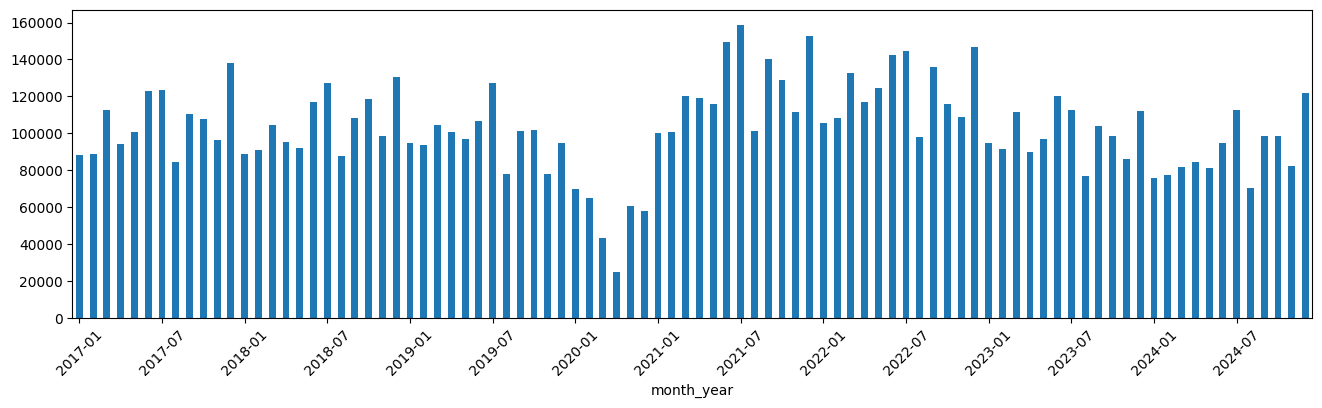

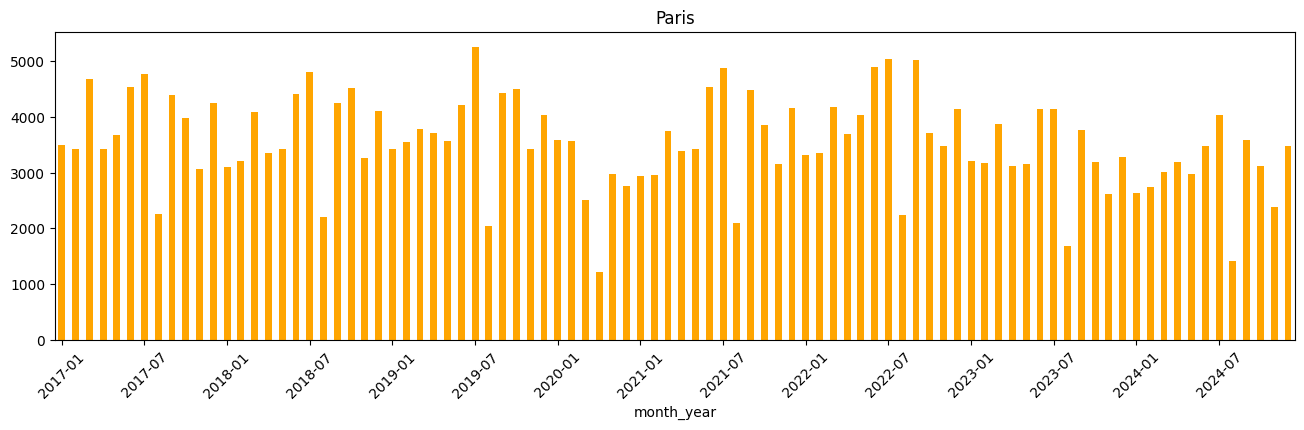

In [8]:
# WYKRES KONTROLNY: LICZBA TRANSAKCJI W POSZCZEGÓLNYCH MIESIĄCACH #

s = data2.drop_duplicates('transaction_id').groupby('month_year').size()
ax = s.plot(kind='bar', figsize=(16,4))
step = 6
ax.set_xticks(range(0, len(s), step))
ax.set_xticklabels(s.index[::step], rotation=45)
plt.show()

s = data2[data2.department_code == '75'].drop_duplicates('transaction_id').groupby('month_year').size()
ax = s.plot(kind='bar', figsize=(16,4), color = 'orange')
step = 6
ax.set_xticks(range(0, len(s), step))
ax.set_xticklabels(s.index[::step], rotation=45)
ax.set_title('Paris')

plt.show()

In [9]:
data2 = data2[(data2.transaction_id.isin(all_ids)) & (data2.transaction_type == 'Sale')] # DUŻO TRANSAKCJI NAM WYRZUCA ZAPEWNE ZWIĄZANYCH Z ZIEMIAMI
data2 = data2[~((data2.transaction_id.isin(apartment_ids)) & (~data2.land_use.isna()))]
size.append(len(data2))


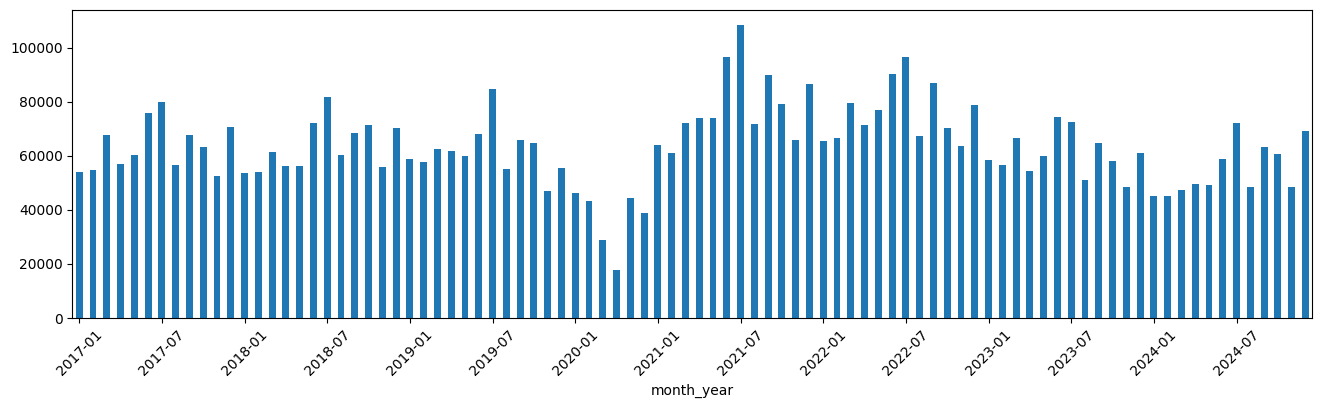

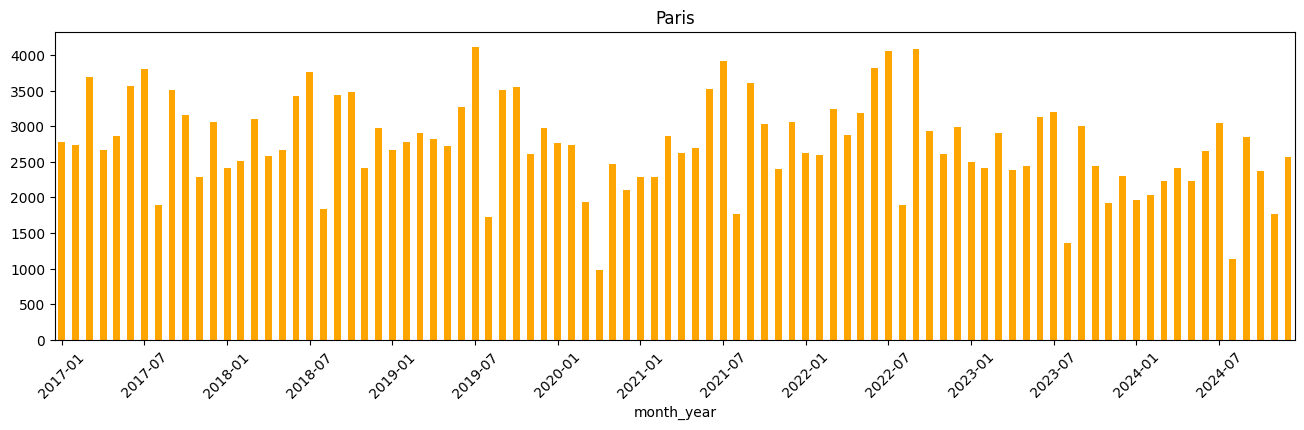

In [10]:
# WYKRES KONTROLNY: LICZBA TRANSAKCJI W POSZCZEGÓLNYCH MIESIĄCACH #

s = data2.drop_duplicates('transaction_id').groupby('month_year').size()
ax = s.plot(kind='bar', figsize=(16,4))
step = 6
ax.set_xticks(range(0, len(s), step))
ax.set_xticklabels(s.index[::step], rotation=45)
plt.show() 

s = data2[data2.department_code == '75'].drop_duplicates('transaction_id').groupby('month_year').size()
ax = s.plot(kind='bar', figsize=(16,4), color = 'orange')
step = 6
ax.set_xticks(range(0, len(s), step))
ax.set_xticklabels(s.index[::step], rotation=45)
ax.set_title('Paris')

plt.show()

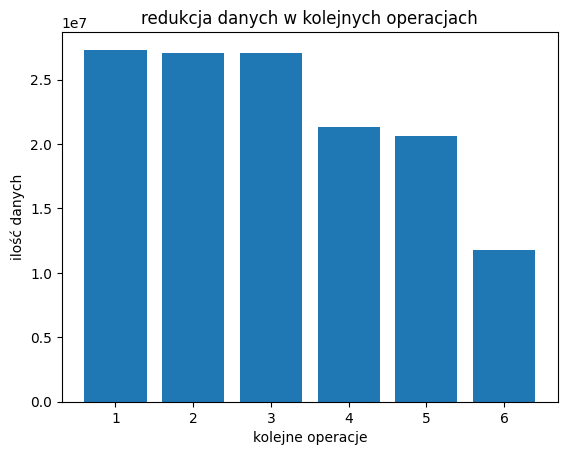

In [11]:
# WYKRES: REDUKCJA DANYCH W KOLEJNYCH OPERACJACH #

plt.bar(np.arange(1, len(size)+1), size)
plt.xlabel('kolejne operacje')
plt.ylabel('ilość danych')
plt.title('redukcja danych w kolejnych operacjach')
plt.show()

In [12]:
data2.to_csv('D:\\nieruchomosci_ostateczne\\samples\\sample_all2.txt', index=False)

In [ ]:
# WYKRES: wizualizujemy rozkłady powierzchni outbuilding i Commercial/Industrial (dla tranzakcji z 1 mieszkaniem, jako wniosek z poprzedniej wizualizacji)
#  plot21 = size_by_type.copy()

# plot21 = size_by_type[size_by_type.transaction_id.isin(one_apartment_many_extra_transaction_ids)].copy()
# plot21 = plot21.rename(columns={c: c.replace("size_", "") for c in plot21.columns})
# plot22 = size_by_type2.loc[size_by_type2.transaction_id.isin(one_apartment_many_extra_transaction_ids), ["n_size_Outbuilding", "n_size_Commercial/Industrial", "n_size_nan_Outbuilding", "n_size_nan_Commercial/Industrial"]].copy()
# col_sums = plot22.sum()

# fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# axes = axes.flatten()

# # wykres 1: rozkład powierzchni pomieszczeń dodatkowych dla tranzakcji z 1 mieszkaniem
# col = "Outbuilding"
# vals = plot21[col]
# vals = vals[vals > 0]

# axes[0].hist(vals, bins=5)
# axes[0].set_title(f"{col} N={len(vals)} dla tranzakcji >=1 mieszkaniowych")
# axes[0].set_xlabel("Powierzchnia (m^2)")
# axes[0].set_ylabel("Liczba transakcji")


# # wykres 2: rozkład powierzchni pomieszczeń industrialnych dla tranzakcji z 1 mieszkaniem
# col = "Commercial/Industrial"
# vals = plot21[col]
# vals = vals[vals > 0]

# upper = vals.quantile(0.95)
# vals = vals[vals <= upper]

# axes[1].hist(vals, bins=40)
# axes[1].set_title(f"{col} (bez top 5% outlierów)\nN={len(vals)} dla tranzakcji >=1 mieszkaniowych")
# axes[1].set_xlabel("Powierzchnia (m^2)")
# axes[1].set_ylabel("Liczba transakcji")

# # wykres 3: liczba pomieszczeń z powierzchniami nan vs not nan
# axes[2].bar(col_sums.index, col_sums.values)
# axes[2].set_title("liczby pomieszczeń dla Outbuilding i Commercial/Industrial \n z powierzchniami nan vs not nan dla tranzakcji >=1 mieszkaniowych")
# axes[2].set_ylabel("Suma")
# axes[2].tick_params(axis="x", rotation=45)

# plt.tight_layout()
# plt.show()

# display(col_sums)

In [ ]:
# x = range(len(size)) 
# plt.plot(x, size, marker="o")
# plt.title("Przykładowy wykres liniowy z punktami")
# plt.xlabel("indeks")
# plt.ylabel("wartość")

# plt.tight_layout()
# plt.show()